#  AISC2009 -  Case Study 2


### 1. Data Preprocessing

In [1]:
# Relevant Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
import itertools

from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# from lime import lime_tabular
from sklearn.decomposition import TruncatedSVD

#### a) Load the data into the dataframe.

In [2]:
df = pd.read_excel('topic_detect/topics.xlsx', dtype_backend='pyarrow')

#### b) Overview

In [3]:
df.head(5)

,title,content,content_word_count,published_date,created_at,updated_at,language,article_links,total_share_count,keywords_status,...,webinar,interview,quote,meme,give_away,quiz,cities_and_states,countries,geo_locations,topic
0,Mitsubishi Motors Co. (OTCMKTS:MMTOF) Short In...,29c9689e5ed81852967ff964f16be109a37dd9ecb1f5c9...,221,2023-04-19 07:26:42,2023-04-19 07:37:59,2023-04-19 07:37:59,en,['https://www.marketbeat.com/stocks/OTCMKTS/MM...,0,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,business
1,Juventus off the hook! Bianconeri set to have ...,b9e3313535ffdbc2fe198572f17ce61330980dfab64324...,225,2023-04-19 06:23:09,2023-04-19 06:44:04,2023-04-19 07:49:41,en,['https://www.gazzetta.it/Calcio/Serie-A/Juven...,0,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,sports
2,Dodgers ponder shortstop for Betts after pater...,2e7bdbd8a033973c2309948b0b1b9de02bf7491e7b464c...,389,2023-04-18 00:00:00,2023-04-19 06:39:02,2023-04-19 06:39:02,en,<NA>,0,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,sports
3,"Meta lays off tech teams, battering employee m...",d4e3c5c938a4c636d40cac488f32cda1cdc02c6372a5f9...,379,2023-04-19 05:27:00,2023-04-19 06:04:15,2023-04-19 07:00:26,en,"['/', '/news/most-popular-news', '/news/econom...",1,True,...,False,False,False,False,False,False,<NA>,<NA>,<NA>,technology
4,FDA clears extra COVID booster for some high-r...,cfd7f633608c252af099ccb7f4a5a02eed9e7c68efe6fb...,856,2023-04-18 02:25:12,2023-04-19 11:01:10,2023-04-19 11:01:10,en,"['https://abcnews.go.com/alerts/Vaccinations',...",0,True,...,False,False,False,False,False,False,['washington'],['united kingdom'],"[{'country': 'GB', 'coordinates': [-1.51667, 5...",health


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype                 
---  ------              --------------  -----                 
 0   title               10000 non-null  string[pyarrow]       
 1   content             10000 non-null  string[pyarrow]       
 2   content_word_count  10000 non-null  int64[pyarrow]        
 3   published_date      10000 non-null  string[pyarrow]       
 4   created_at          10000 non-null  timestamp[us][pyarrow]
 5   updated_at          10000 non-null  timestamp[us][pyarrow]
 6   language            10000 non-null  string[pyarrow]       
 7   article_links       7104 non-null   string[pyarrow]       
 8   total_share_count   9999 non-null   int64[pyarrow]        
 9   keywords_status     9979 non-null   bool[pyarrow]         
 10  keywords            9979 non-null   string[pyarrow]       
 11  entities            9979 non-null   string[pyarrow]   

In [5]:
text_folder = 'topic_detect/text'

In [6]:
import os

files_content = {}

for filename in os.listdir(text_folder):
    if filename.endswith(".txt"):
        with open(os.path.join(text_folder, filename), 'r') as file:
            content = file.read()
            files_content[filename] = content  # store content in dictionary using filename as key

In [7]:
df['Combined_Text'] = df['content'].map(files_content)

In [8]:
# Get the shape 
print("Data Shape:", df.shape)

Data Shape: (10001, 31)


In [9]:
# Display unique values in the 'topic' column
unique_topics = df['topic'].unique()
print("Unique Topics:")
print(unique_topics)

Unique Topics:
<ArrowExtensionArray>
[     'business',        'sports',    'technology',        'health',
       'unknown',      'politics',        'travel', 'entertainment',
       'fashion']
Length: 9, dtype: string[pyarrow]


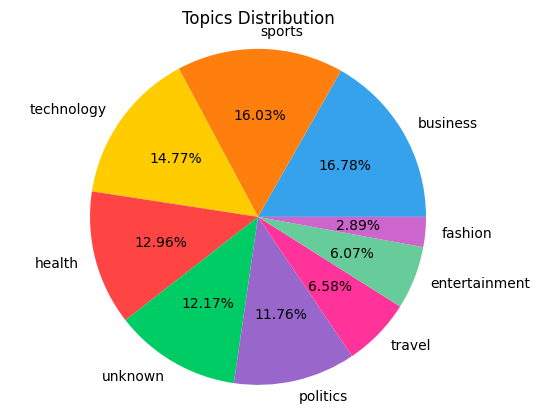

In [10]:
# Distribution of Topics 
labels = unique_topics
sizes = df["topic"].value_counts()
colors = ["#36a2eb", "#ff7f0e", "#ffcc00", "#ff4444", "#00cc66", "#9966cc", "#ff3399", "#66cc99", "#cc66cc"]

plt.title("Topics Distribution")
plt.pie(sizes, labels=labels, autopct="%0.2f%%", colors=colors)
plt.axis('equal')
plt.show()

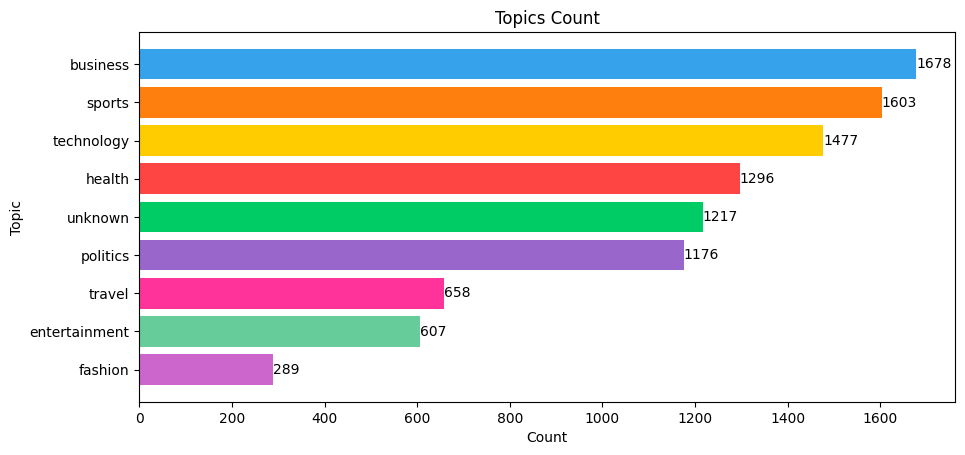

In [11]:
# Bar plot to see the count of each Sentiment
# Check if data is Balanced or Imbalanced
for i, size in enumerate(sizes):
    plt.text(size, i, str(size), ha='left', va='center')  # Adjust ha and va for positioning

plt.barh(labels, sizes, color=colors)  # Use plt.barh() for horizontal bar plot
plt.xlabel("Count")
plt.ylabel("Topic")  # Put the Topic labels on the y-axis
plt.title("Topics Count")
plt.gca().invert_yaxis()  # Invert the y-axis to display topics from top to bottom
plt.subplots_adjust(right=1.4)
# plt.tight_layout()  # Ensures the plot labels are not cut off
plt.show()


#### c) Handle null values and choose features to focus on.

In [12]:
# Create a new DataFrame with only the desired columns
selected_columns = ['title', 'content', 'Combined_Text', 'topic']
df = df[selected_columns].copy()

# Capitalize the first letter of the column names
df.rename(columns={col: col.capitalize() for col in df.columns}, inplace=True)
df.head()

,Title,Content,Combined_text,Topic
0,Mitsubishi Motors Co. (OTCMKTS:MMTOF) Short In...,29c9689e5ed81852967ff964f16be109a37dd9ecb1f5c9...,Mitsubishi Motors Co. (OTCMKTS:MMTOF – Get Rat...,business
1,Juventus off the hook! Bianconeri set to have ...,b9e3313535ffdbc2fe198572f17ce61330980dfab64324...,New legal developments could prompt a reversal...,sports
2,Dodgers ponder shortstop for Betts after pater...,2e7bdbd8a033973c2309948b0b1b9de02bf7491e7b464c...,NaN,sports
3,"Meta lays off tech teams, battering employee m...",d4e3c5c938a4c636d40cac488f32cda1cdc02c6372a5f9...,Oil falls 2% as U. S. dollar strengthens on Fe...,technology
4,FDA clears extra COVID booster for some high-r...,cfd7f633608c252af099ccb7f4a5a02eed9e7c68efe6fb...,Certain Americans at high risk from COVID-19 c...,health


In [13]:
# Check null values
df.isna().sum()

Title              1
Content            1
Combined_text    349
Topic              0
dtype: int64

In [14]:
# Drop null values
df = df.dropna()

# Check updated values
# print(df.isna().sum())

In [15]:
df.isna().sum()

Title            0
Content          0
Combined_text    0
Topic            0
dtype: int64

In [16]:
# Get the shape 
print("Data Shape:", df.shape)

Data Shape: (9652, 4)


In [17]:
# Check Content word count
content_word_count = df['Content'].apply(lambda x: len(str(x).split(" ")))
title_word_count = df['Title'].apply(lambda x: len(str(x).split(" ")))
con_max_word_count = content_word_count .max()
tit_max_word_count = title_word_count.max()
print("Maximum Word Count")
print("Content:\t", con_max_word_count)
print("Title:\t\t", tit_max_word_count)

Maximum Word Count
Content:	 1
Title:		 46


In [18]:
# Overview
num_samples = 5
random_samples = df.sample(num_samples)
random_samples.head()

,Title,Content,Combined_text,Topic
8824,"FY2023 Earnings Forecast for Honda Motor Co., ...",67a62d710b83e2dc32d9a0beae46a23411771eb4054580...,"Honda Motor Co., Ltd. (NYSE:HMC – Get Rating) ...",business
658,Working With C4Dâ€™s New Symmetry Object to Cr...,ed87df4cb113240ab6bf5a85280faa1dad6fbbe0ab6747...,Working With C4D’s New Symmetry Object to Crea...,technology
3210,"CCCT with Cloteen Jasmin, Atlanta Market Leade...",135cfeded7de02241dcafbaf55b403f3e3ffd2c8575be6...,"Skip to content\n\nCCCT with Cloteen Jasmin, A...",business
6580,Decred (DCR) Price Reaches $21.88,70d94bcdb863466c5c68538d2073ab3afb820608905c98...,Decred (DCR) traded up 2.4% against the U. S. ...,business
365,Perthâ€™s first high-rise primary school revealed,50e8efd3e3f4f9f1328975c4590283970ec75e0ccb6bce...,"We’re sorry, this feature is currently unavail...",politics


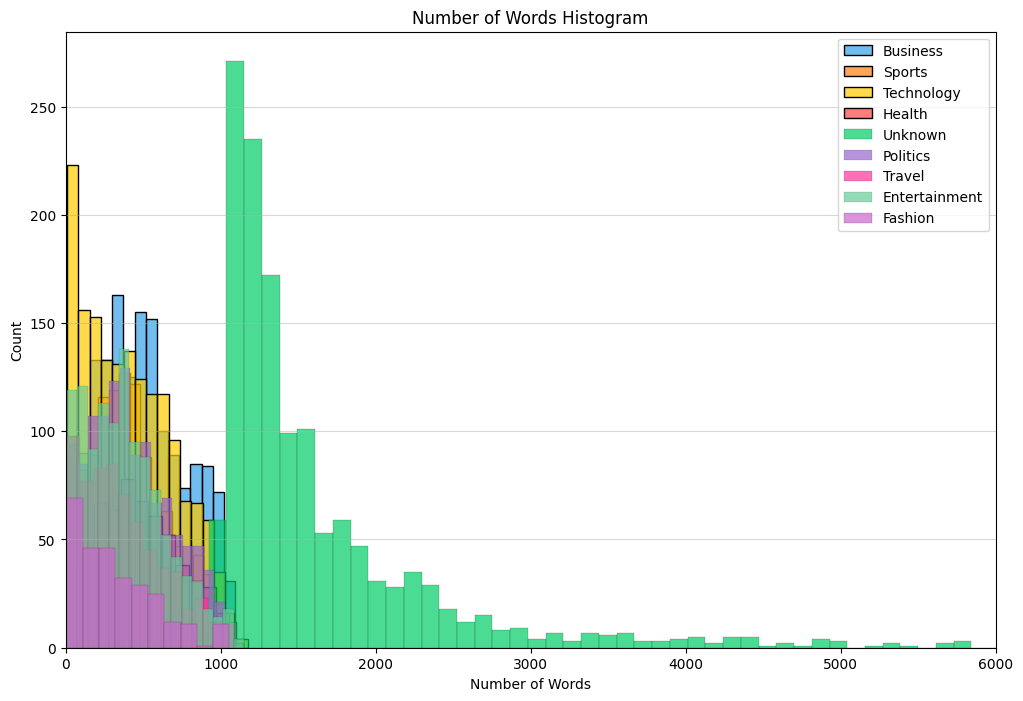

In [19]:
# Fetch the number of Words
df["Num_Words"] = df['Combined_text'].apply(lambda x: len(nltk.word_tokenize(x)))

# 9 Colors
colors = ["#36a2eb", "#ff7f0e", "#ffcc00", "#ff4444", "#00cc66", "#9966cc", "#ff3399", "#66cc99", "#cc66cc"]

# Figure Size
plt.figure(figsize=(12, 8))

# Adjust the colors and add a label
for idx, topic in enumerate(df["Topic"].unique()):
    sns.histplot(df[df["Topic"] == topic]["Num_Words"], color=colors[idx], label=topic.capitalize(), alpha=0.7)

# Axis Labels and Title
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.title("Number of Words Histogram")
plt.legend()

# Set a light grid to improve visibility
plt.grid(axis='y', alpha=0.5)

plt.xlim(0, 6000)
plt.show()

### Standardize the data (Log Transformation)

#### Transforming all to the same scale. Some models perform better when all features are at the same scale.

- Original Dataset to Log Transformed Dataset
- Pulls the long tail of the skewed dataset and all those outliers back towards the bulk of the data
- This helps the model draw correlations and better understand the data without trying to overfit the long tail and those outliers

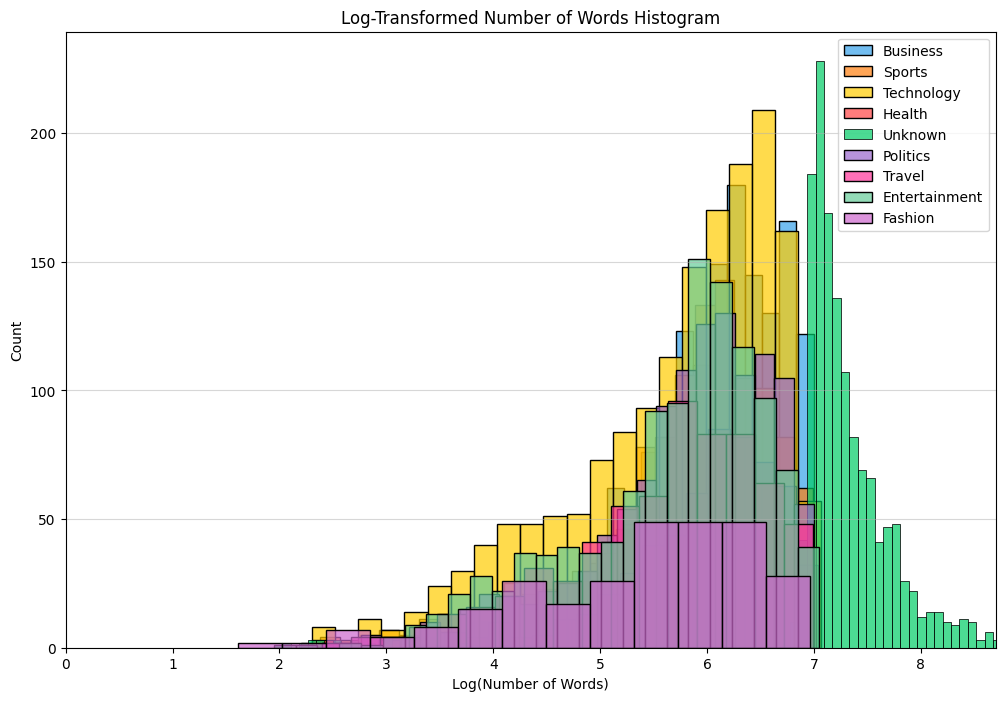

In [20]:
# Log-transform the data
df["Log_Num_Words"] = np.log(df["Num_Words"])

# Figure Size
plt.figure(figsize=(12, 8))

# Adjust the colors and add a label
for idx, topic in enumerate(df["Topic"].unique()):
    sns.histplot(df[df["Topic"] == topic]["Log_Num_Words"], color=colors[idx], label=topic.capitalize(), alpha=0.7)

# Axis Labels and Title
plt.xlabel("Log(Number of Words)")
plt.ylabel("Count")
plt.title("Log-Transformed Number of Words Histogram")
plt.legend()

# Set a light grid to improve visibility
plt.grid(axis='y', alpha=0.5)

plt.xlim(0, np.log(6000))
plt.show()

#### d) Preprocess the text data by removing special characters, punctuations, and numbers.

In [21]:
def clean_text(text):
    if not isinstance(text, str):
        return ''

    # Remove non-ASCII characters and special characters
#     text = text.encode('ascii', 'ignore').decode('ascii').replace("â", "")

    # Replace HTML entities with their respective symbols
    html_entities = {
        "&amp;": "&",
        "&lt;": "<",
        "&gt;": ">",
        "&quot;": '"',
        "&apos;": "'"
    }
    for entity, symbol in html_entities.items():
        text = text.replace(entity, symbol)

        
        
    # Combine regex patterns to handle backticks, URLs, and "www" and also remove numbers without spaces
    text = re.sub(r'https?://\S+|https?://t\.co/\S+|www\S+|\b\d+(?:\s+\d+)*\s*|(?<=\b\d) (?=\w)', '', text)


    # Remove @mentions, email addresses, hashtags, @ signs, and punctuation
    text = re.sub(r'@[^\s]+', ' ', text)
    text = re.sub(r'[^\s]+@[^\s]+', ' ', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    
    text = re.sub(r'[$]+', 'dollar ', text)  # Handle $ sign
    text = re.sub(r'[\n]+', ' ', text)  # Remove \n
    text = re.sub(r'[{0}]'.format(string.punctuation), ' ', text)  # Remove remaining punctuation
    text = re.sub(r'(\s)+', ' ', text)  # Remove extra whitespaces
    text = re.sub(r'(\s)+', ' ', text)  # Remove extra whitespaces
    text = text.strip()  # Remove leading and trailing whitespaces
    text = text.lower()  # Convert tweet to lowercase
    
    # Replace "nt" with "not" using regex
    text = re.sub(r"\b(\w+)\s*nt\b", r"\1 not", text, flags=re.IGNORECASE)
    
    return text

#### e) Remove stop words

In [22]:
# Convert NLTK stopwords to a set for faster lookup
stop_words = set(stopwords.words('english'))

def remove_stop_words(tokens):
    # Convert the tokens to lowercase
    tokens = [token.lower() for token in tokens]
    # Remove stopwords and punctuation from the list of tokens
    cleaned_tokens = [token for token in tokens if token not in stop_words and token not in string.punctuation]
    return cleaned_tokens

#### f) Stemming

In [23]:
# Function for stemming using PorterStemmer
def stemming(tokens):
    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens

#### g) POS Tagging and Lemmatizing

In [24]:
# Parts of Speech Tagging for each word will help lemmatizer function to output better accuracy
def get_wordnet_pos(tag):
    """
    Map POS tag to WordNet POS tag
    """
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  
    

def lemmatizing(tokens):
    wn = nltk.WordNetLemmatizer()
    pos_tags = nltk.pos_tag(tokens)
    lemmatized_tweet = [wn.lemmatize(token, pos=get_wordnet_pos(tag)) for token, tag in pos_tags]
    return pos_tags, lemmatized_tweet  

#### h) Apply Functions 

In [28]:
nltk.download('averaged_perceptron_tagger')
df['Cleaned_Text'] = df['Combined_text'].apply(clean_text)
df['Tokenized_Text'] = df['Cleaned_Text'].apply(word_tokenize)
df['Tokenized_Text'] = df['Tokenized_Text'].apply(remove_stop_words)
# df["Stemmed_Text"] = df["Tokenized_Text"].apply(lambda x: stemming(x))
df["POS_Tags"], df["Lemmatized_Text"] = zip(*df["Stemmed_Text"].apply(lemmatizing))

df.head()

[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify
[nltk_data]     failed: unable to get local issuer certificate
[nltk_data]     (_ssl.c:992)>


LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger/averaged_perceptron_tagger.pickle[0m

  Searched in:
    - '/Users/aashishtangnami/nltk_data'
    - '/Users/aashishtangnami/Documents/Projects/nlp_week_13/venv/nltk_data'
    - '/Users/aashishtangnami/Documents/Projects/nlp_week_13/venv/share/nltk_data'
    - '/Users/aashishtangnami/Documents/Projects/nlp_week_13/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
df['Combined_Text'] = df['Combined_text']


#### i) Observations

In [ ]:
# Display the first two samples of "Combined_Text" and "Lemmatized_Text"
print("Sample of Combined_Text:\n")
print(df["Combined_Text"].head(1).values)

print("=" * 88)

print("\nSample of Cleaned_Text:\n")
print(df["Cleaned_Text"].head(1).values)

print("=" * 88)

print("\nSample of Lemmatized_Text:\n")
print(df["Lemmatized_Text"].head(1).values)

In [ ]:
# Check latest word count
com_word_count = df['Combined_Text'].apply(lambda x: len(str(x).split(" ")))
lem_word_count = df['Lemmatized_Text'].apply(lambda x: len(str(x).split(" ")))
com_max_word_count = com_word_count .max()
lem_max_word_count = lem_word_count .max()
eliminated = com_max_word_count - lem_max_word_count

print("Word Count \nCombined Title and Content Text:\t", com_max_word_count)
print("\nNo. of words eliminated:\t\t", eliminated)


print("\nLatest Word Count")
print("Lemmatized Text:\t\t\t", lem_max_word_count)

In [ ]:
df['lem_word_count'] = df['Lemmatized_Text'].apply(lambda x: len(str(x).split(" ")))

In [ ]:
df['lem_word_count'].idxmax()

In [ ]:
# Drop the entire row at index 7387
df = df.drop(7387)


In [ ]:
# Step 1: Calculate word count for each row
df['Word_Count'] = df['Lemmatized_Text'].apply(lambda x: len(x.split()))

# Step 2: Sort the DataFrame based on Word_Count in descending order
df_sorted = df.sort_values(by='Word_Count', ascending=False)

# Step 3: Print the top 10 rows with the maximum number of words
top_10_max_word_count = df_sorted.head(10)
print(top_10_max_word_count)


**Observation**

- After preprocessing, we were able to lessen the dimension of our dataset. Focusing on the lemmatized contents of each text file.

### 2. Feature Extraction with Bag of Words

 - Use Term Frequency-Inverse Document Frequency (TF-IDF) representation to convert the Bag of Words vectors into TF-IDF vectors.

 - TF-IDF assigns a weight to each word based on its importance in the document relative to the entire corpus.


 - TF-IDF is giving us only 149 vectors

- 2.a) Bag of Words representation of the preprocessed text data.
- 2.b) Build a vocabulary of unique words (terms) present in the text data.
- 2.c) Count the occurrences of each term in each document (text sample).
- 2.d) Represent each document as a vector with the Count Vectorizer of the vocabulary words.

In [ ]:
# TF-IDF Vectorizer Approach for Bag of Words Model

# Convert the lists of tokens into strings
df['Lemmatized_Text'] = df['Lemmatized_Text'].apply(lambda tokens: ' '.join(tokens))

# Create the Transform with min_df to limit the vocabulary
min_word_freq = 5
vectorizer = TfidfVectorizer(min_df=min_word_freq, max_features=8300)

# Tokenize and build vocabulary
vectorizer.fit_transform(df["Lemmatized_Text"])

# Show 10 vocabulary
limited_vocab = dict(itertools.islice(vectorizer.vocabulary_.items(), 10))
print("Vocabulary sample:")
print(limited_vocab)

# Encode Document
bag_of_words = vectorizer.transform(df["Lemmatized_Text"])

print("\nBag of Words Shape:")
print(bag_of_words.shape)

# Sparse matrix to a dense array
bag_of_words_array = bag_of_words.toarray()

# DataFrame for the Bag of Words representation
bag_of_words_df = pd.DataFrame(bag_of_words_array, columns=vectorizer.get_feature_names_out())


print("\nBag of Words Data Frame:")
bag_of_words_df.head()

#### Log Transformation on Vectors to Normalize the data

In [ ]:
# # Apply log transformation to the vector to address the imbalaced/ skewed data
# log_transformed_vector = np.log1p(embedding_df)

# # Print the first 5 rows of the original and log-transformed DataFrames
# print("Original DataFrame:")
# print(embedding_df.head(3))

# print("\n\nLog-Transformed DataFrame:")
# print(log_transformed_vector.head(3))

### 3. Dense Representation with Word Embeddings ( GloVe and Word2Vec )

By using GloVe, we transform each document into a fixed-length vector representation by averaging the word embeddings of the words present in the document.

- Training Approach:
    1. GloVe uses a global word-word co-occurrence matrix to learn word embeddings, capturing global word associations.

- Pros:
    1. Handles Out of Vocabulary words better compared to Word2Vec.
    2. Can capture both local and global word relationships.
    3. Performs well even with smaller training datasets.

- Cons:
    1. Might not capture fine-grained semantic relationships as effectively as Word2Vec.

In [ ]:
# Path to the downloaded Word2Vec model file
model_path = "/Users/mialaarnigarcia/Downloads/GoogleNews-vectors-negative300.bin"
model = KeyedVectors.load_word2vec_format(model_path, binary=True)

In [ ]:
glove_model_path = "/Users/mialaarnigarcia/Downloads/glove.6B/glove.6B.100d.txt"
file_word2vec = "/Users/mialaarnigarcia/Downloads/glove.6B/word2vec.txt"

# Convert the GloVe model to Word2Vec format
glove2word2vec(glove_model_path, file_word2vec)

# Load the Word2Vec model
glove_model = KeyedVectors.load_word2vec_format(file_word2vec, binary=False)

In [ ]:
# Function to compute the word embedding for each word in the vocabulary
def word_embedding(word):
    # Check if the word is in the vocab
    if word in glove_model:
        return glove_model[word]
    else:
        # Return a zero vector when word is not in vocab
        return np.zeros(glove_model.vector_size)

# Apply the word_embedding to each word in the bag_of_words_df 
word_embeddings = bag_of_words_df.applymap(word_embedding)

# To compute document embeddings for all rows in the DataFrame
def document_embedding(row):
    return row.mean()

# Compute document embeddings for all rows in the DataFrame
document_embeddings = word_embeddings.apply(document_embedding, axis=1)

# Store the document embeddings
embedding_df = pd.DataFrame(document_embeddings.tolist(), index=word_embeddings.index)


print("\nPretrained Embedding Shape:")
print(embedding_df.shape)

print("\nWord Embeddings of BoW Data Frame:")
print(embedding_df.head())

## 4. Split Data into Training and Testing Sets

Split your dataset into a training set and a testing set. The training set will be used to train the SVM model, and the testing set will be used to evaluate its performance.

### 4.a) Split for SVM with Bag of Words

In [ ]:
# Bag of Words Representation
X_bow = bag_of_words_df.values
y = df["Topic"].values

# First, split the dataset into training+validation and testing sets
X_temp_bow, X_test_bow, y_temp_bow, y_test_bow = train_test_split(X_bow, y, test_size=0.2, random_state=42)

# Then split the temporary set into separate training and validation sets
X_train_bow, X_val_bow, y_train_bow, y_val_bow = train_test_split(X_temp_bow, y_temp_bow, test_size=0.25, random_state=42)

# Sampler
smote = SMOTE(sampling_strategy='auto')

# Fit and resample the training data
X_train_res_bow, y_train_res_bow = smote.fit_resample(X_train_bow, y_train_bow)

print("Shape of X (Bag of Words Representation):", X_bow.shape)
print("\nShape of y (target variable):", y.shape)
print("\nShape of X_train_res_bow:", X_train_res_bow.shape)
print("Shape of X_test_bow:", X_test_bow.shape)
print("Shape of X_val_bow:", X_val_bow.shape)
print("Shape of y_train_res_bow:", y_train_res_bow.shape)
print("Shape of y_val_bow:", y_val_bow.shape)
print("Shape of y_test_bow:", y_test_bow.shape)

### 4.b) Split for SVM with Pre-trained Embeddings

In [ ]:
X = embedding_df.values
y = df["Topic"].values

# First, split the dataset into training+validation and testing sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then split the temporary set into separate training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Sampler
smote = SMOTE(sampling_strategy='auto')

# Fit and resample the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


print("Shape of X (Word Embedding Representation):", X.shape)
print("\nShape of y (target variable):", y.shape)
print("\nShape of X_train_res:", X_train_res.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train_res:", y_train_res.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encoding for Pre-trained Embeddings
encoder = LabelEncoder()
encoder.fit(y_train_res)
Y_train = encoder.transform(y_train_res)
encoder.fit(y_test)
Y_test = encoder.transform(y_test)

# Label encoding for Bag of Words
encoder.fit(y_train_res_bow)
Y_train_bow = encoder.transform(y_train_res_bow)
encoder.fit(y_test_bow)
Y_test_bow = encoder.transform(y_test_bow)


In [ ]:
ytest_emb_class_distribution = pd.Series(y_test).value_counts()
ytrain_emb_class_distribution = pd.Series(y_train_res).value_counts()

# Pre-trained Word Embeddings class distribution
print("Pre-trained Word Embeddings Class Distribution")
print("\nTest Set:")
print(ytest_emb_class_distribution)
print("\nTrain Set:")
print(ytrain_emb_class_distribution)

ytest_bow_class_distribution = pd.Series(y_test_bow).value_counts()
ytrain_bow_class_distribution = pd.Series(y_train_res_bow).value_counts()

# Bag of Words class distribution
print("\n\nBag of Words Class Distribution")
print("\nTest Set:")
print(ytest_bow_class_distribution)
print("\nTrain Set:")
print(ytrain_emb_class_distribution)

### 5) Train the SVM Model with GridSearch

5.a) Initialize an SVM classifier with the appropriate kernel (e.g., linear, polynomial, or radial basis function).

- Performed hyperparameter tuning on the SVM model to find the best combination of hyperparameters that optimize the model's performance.
- Hyperparameters tuned include the SVM kernel type, regularization parameter (C), and gamma for the RBF (radial basis function kernel).

5.b) Train the SVM model on the training data using the best parameters found on the GridSearch and LIME to explain the prediction of the model.

In [ ]:
# Define the parameters for the grid search
parameters = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}

svm_classifier = SVC(decision_function_shape='ovo')

# Perform grid search to find the best parameters
grid_search = GridSearchCV(svm_classifier, parameters, cv=5, n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("\nBest Parameters for Embedded Words:", best_params)

####  Tried performing GridSearch to Bag of Words, ended up to dead kernel every run, due to the shape of BoW Representation is too big.

In [ ]:
# # Define the parameters for the grid search
# parameters = {
#     "kernel": ["linear", "rbf", "poly"],
#     "C": [0.1, 1, 10],
#     "gamma": ["scale", "auto"]
# }

# svm_classifier = SVC(decision_function_shape='ovo')

# grid_search = GridSearchCV(svm_classifier, parameters, cv=5, n_jobs=-1)

# # Fit the grid search to BoW Data
# grid_search.fit(X_train_res_bow, y_train_res_bow)

# # Get the best parameters and best estimator
# best_params_bow = grid_search.best_params_
# best_estimator = grid_search.best_estimator_

# print("\nBest Parameters for Bag of Words:", best_params_bow)

### 5.a) SVM with Bag of Words Training

In [ ]:
# SVM classifier with the best parameters for BoW
svm_classifier_bow = SVC(**best_params, decision_function_shape='ovo')
svm_classifier_bow.fit(X_train_res_bow, y_train_res_bow)

### 5.b) SVM with Pretrained Embeddings Training

In [ ]:
# SVM classifier with the best parameters for Word Embeddings
svm_classifier_embed = SVC(**best_params, decision_function_shape='ovo')
svm_classifier_embed.fit(X_train_res, y_train_res)

### 5.c) Lime Text Explainer

In [ ]:
from lime import lime_text
from sklearn.pipeline import make_pipeline
from lime.lime_text import LimeTextExplainer

# Create a text explainer for BoW
explainer_bow = LimeTextExplainer(class_names=list(encoder.classes_))

# Function to predict using SVM classifier on BoW data
def predict_bow(texts):
    vectors = vectorizer.transform(texts)
    return svm_classifier_bow.predict(vectors)

# Choose an instance for explanation
instance_idx = 0
instance_text = df["Lemmatized_Text"].iloc[instance_idx]

# Explain the prediction for the chosen instance
exp_bow = explainer_bow.explain_instance(instance_text, predict_bow, num_features=10)

# Show explanation
exp_bow.show_in_notebook(text=True)

In [ ]:
from lime import lime_tabular

# Create a tabular explainer for Word Embeddings
explainer_embed = lime_tabular.LimeTabularExplainer(X_train_res, feature_names=list(embedding_df.columns), class_names=list(encoder.classes_))

# Function to predict using SVM classifier on Word Embeddings data
def predict_embed(X):
    return svm_classifier_embed.predict(X)

# Choose an instance for explanation
instance_idx = 0
instance_vector = X_train_res[instance_idx]

# Explain the prediction for the chosen instance
exp_embed = explainer_embed.explain_instance(instance_vector, predict_embed, num_features=10)

# Show explanation
exp_embed.show_in_notebook()

## 6. Predictions 

After satisfaction with the SVM model's performance, we can now use it to make predictions on new, unseen text data to detect topics.

### 6.a) Predictions using SVM with Bag of Words

In [ ]:
# Make predictions on the test set using the trained SVM classifier for BoW
y_pred_bow = svm_classifier_bow.predict(X_test_bow)

# Convert the encoded labels back to their original classes
y_pred_bow = encoder.inverse_transform(y_pred_bow)

# Calculate accuracy and other metrics for BoW predictions
accuracy_bow = accuracy_score(y_test_bow, y_pred_bow)
print("Accuracy for BoW:", accuracy_bow)

### 6.b) Predictions using SVM with Pre-trained Embeddings

In [ ]:
# Make predictions on the test set using the trained SVM classifier for Word Embeddings
y_pred_embed = svm_classifier_embed.predict(X_test_embed)

# Convert the encoded labels back to their original classes
y_pred_embed = encoder.inverse_transform(y_pred_embed)

# Calculate accuracy and other metrics for Word Embeddings predictions
accuracy_embed = accuracy_score(y_test_embed, y_pred_embed)
print("Accuracy for Word Embeddings:", accuracy_embed)

In [ ]:
# TruncatedSVD
svd = TruncatedSVD(n_components=2)
X_test_svd = svd.fit_transform(X_test_vect)

plt.figure(figsize=(8, 8))
plt.scatter(X_test_svd[:, 0], X_test_svd[:, 1], c=y_test_pred, cmap='viridis')
plt.title('2D representation of the data (predicted labels)')
plt.show()

### 7. Evaluate the SVM Model


- Use the trained SVM model to predict the topics for the documents in the testing set.
- Compare the predicted topics with the actual topic labels in the testing set.
- Evaluate the performance of the SVM model using metrics like accuracy, precision, recall, F1-score, etc.

In [ ]:
# You can also print classification report and confusion matrix for BoW predictions
print("Classification Report for BoW:")
print(classification_report(y_test_bow, y_pred_bow))

print("Confusion Matrix for BoW:")
print(confusion_matrix(y_test_bow, y_pred_bow))

# Plot the confusion matrix
sns.heatmap(confusion_matrix(y_test_bow, y_test_pred_bow), annot=True, fmt='d')
plt.show()

In [ ]:
# You can also print classification report and confusion matrix for Word Embeddings predictions
print("Classification Report for Word Embeddings:")
print(classification_report(y_test_embed, y_pred_embed))

print("Confusion Matrix for Word Embeddings:")
print(confusion_matrix(y_test_embed, y_pred_embed))

# Plot the confusion matrix
sns.heatmap(confusion_matrix(y_test_embed, y_test_pred_embed), annot=True, fmt='d')
plt.show()

In [ ]:
# print(f"Training Accuracy: {train_accuracy}")
# print(f"Validation Accuracy: {val_accuracy}")
# print(f"Test Accuracy: {test_accuracy}")

# # Classification report
# print("Classification Report:")
# print(classification_report(y_test, y_test_pred))

# # Print the confusion matrix
# print("Confusion Matrix:")
# print(confusion_matrix(y_test, y_test_pred))

# # Plot the confusion matrix
# sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')
# plt.show()

### 8. Area Under the Curve

In [ ]:
from sklearn.metrics import RocCurveDisplay

# ROC AUC Curve Function
def plot_roc_auc(classifier, X_train, y_train, X_test, y_test):
    # Fit the classifier on the training data
    classifier.fit(X_train, y_train)
    
    # Predict probabilities for the test data
    y_scores = classifier.predict_proba(X_test)[:, 1]

    # Calculate the false positive rate, true positive rate, and thresholds
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    
    # Calculate the AUC score
    roc_auc = auc(fpr, tpr)
    
    # Create RocCurveDisplay
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='Classifier')
    
    # Plot the ROC curve with the specified color
    roc_display.plot(color='darkorange')
    
    # Customize the plot
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
# Support Vector Machine with Bag of Words
plot_roc_auc(svm_classifier, X_train_bow, y_train_bow, X_test_bow, y_test_bow)

In [ ]:
# Support Vector Machine with Pre-trained Word Embeddings
plot_roc_auc(svm_classifier, X_train_embed, y_train_embed, X_test_embed, y_test_embed)

### Summary

Model built, train and test handled correctly?

 - Experienced Bottleneck - Embedding the bag of words using GloVe. Kernel stopped working after multiple attempts.
 - From 300 embedding dimension, I tried 100 next.
 - Tried Google News Vectors


Evaluation - Confusion Matrix, what is the AUC value?
 - First Run was giving less than 10% Accuracy.
 - Reviewed the Preprocessing step taken.

1st round of tuning - What was the issue faced/tuned?
 - Training Accuracy was less than 10%

2nd round of tuning - What was the issue faced/tuned? 
 - Tried SVM with Grid Search
 - Switched to TF-IDF
 - Standard Scaler to deal with imbalanced data
 - Used RandomSampler
 - Increased Training Accuracy around 17%

3rd round of tuning - What was the issue faced/tuned? 
 - Applied Log Transformation
 - SMOTE Sampler
 - Decreased Training Accuracy to 10%

3rd round of tuning - What was the issue faced/tuned? 
 - Added LIME to explain SVM's prediction

Interpretation using Lime
 - Insert here
 
 
Final AUC value? Next steps Recommended?

### 9. Deep Learning Model

In [ ]:
# Necessary Libraries
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
import tensorflow as tf  # Deep learning framework
from tensorflow.keras.layers import LSTM, Dropout, Dense, Embedding, Bidirectional  # Layers for building models
from tensorflow.keras.models import Sequential  # Sequential model
from tensorflow.keras.optimizers import Adam  # Optimization algorithm
from tensorflow.keras.callbacks import EarlyStopping  # Early stopping for model training

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df.Combined_Text)

sequences = tokenizer.texts_to_sequences(df.title_content_text)

extract_features = pd.DataFrame(data= sequences)
target = df.Topic

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

In [ ]:
df_final = pd.concat([extract_features, target], axis=1)

EMBEDDING_DIM = 300  # or whatever your GloVe embeddings dimension is

embedding_matrix = np.zeros((len(word_index) + 1, EMBEDDING_DIM))
for word, i in word_index.items():
    if word in model.key_to_index:
        embedding_vector = model[word]
        if embedding_vector is not None:
            
            embedding_matrix[i] = embedding_vector

from keras.layers import Embedding

embedding_layer = Embedding(len(word_index) + 1,
                            EMBEDDING_DIM,
                            weights=[embedding_matrix],
                            trainable=False)

In [ ]:
X = df_final.drop("Topic",axis=1)
y = df_final["Topic"]

X_train_val,X_test,y_train_val,y_test = train_test_split(X, y, random_state=42, test_size=0.45)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, random_state=42, test_size=0.50)

In [ ]:
# Define the model
vocab_size = 8300
sentence_len = 700
feature_num = 8300

lstm_model = Sequential()
lstm_model.add(embedding_layer)
lstm_model.add(Bidirectional(LSTM(units=128)))  # Make LSTM layer bidirectional
lstm_model.add(Dropout(0.4))
lstm_model.add(Dense(units=80, activation='relu'))
lstm_model.add(Dense(units=50, activation='relu'))
lstm_model.add(Dense(units=1, activation='softmax'))

In [ ]:
# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Set up early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=15, batch_size=32, callbacks=[early_stopping])

### 10. Model Selection